En esta actividad, vamos a poner en práctica todo lo que aprendimos sobre procesamiento de imágenes para crear un proyecto.

Objetivo: El objetivo de este proyecto es que utilicen procedimientos básicos de procesamiento de imágenes para leer una imagen, aplicarle mejoras, segmentar objetos y mostrar los resultados en una presentación visual.

Duración: Tenemos 1 hora para completar este desafío.

##Preparación:

Entorno: Vamos a usar Google Colab, que ya tiene todo lo que necesitamos instalado.

##Imágenes:

Les voy a proporcionar un conjunto de imágenes de ejemplo para que elijan la que más les guste. Hay de todo un poco: paisajes, objetos, retratos... ¡para que tengan variedad!

Si prefieren, ¡pueden usar sus propias fotos! Solo recuerden elegir una imagen con buena iluminación y calidad para que los resultados sean los mejores.

Google Colab: Este cuaderno ya está listo para que trabajen. Solo tienen que seguir las instrucciones y completar el código en los espacios indicados.

Pasos a seguir:

##1. ¡Empecemos importando las bibliotecas!
Lo primero que vamos a hacer es importar las herramientas que vamos a utilizar.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Leyendo y viendo nuestra imagen
Subir la imagen: Si van a usar una foto propia, súbanla a Google Colab. Para hacerlo, hagan clic en el ícono de la carpeta en la barra lateral izquierda, luego en el ícono de "Subir" y seleccionen su archivo.

Leer la imagen: Con cv2.imread(), vamos a leer la imagen que eligieron. Recuerden que OpenCV lee las imágenes en formato BGR, así que la vamos a convertir a RGB para poder verla bien con Matplotlib.

Mostrar la imagen original: Usaremos matplotlib.pyplot para ver la imagen tal como es al principio.

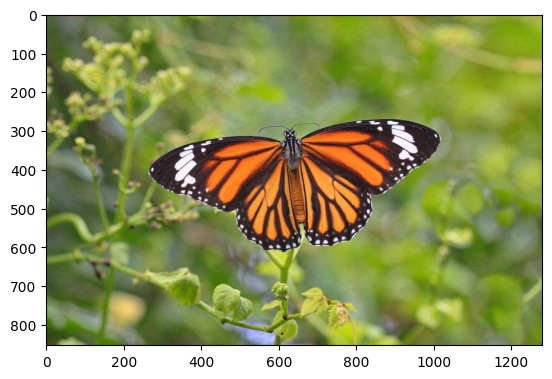

In [32]:
imagen = cv2.imread('/content/mariposa.jpg')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
plt.imshow(imagen)
plt.show()

##3. ¡Mejorando nuestra imagen!
Ahora vamos a aplicar un par de técnicas para que nuestra imagen se vea aún mejor:

Ajuste de brillo y contraste: Vamos a crear una función para modificar estos aspectos de la imagen.

Ecualización de histograma: Con cv2.equalizeHist(), vamos a mejorar el contraste de la imagen.

In [33]:
# Ajuste de brillo y contraste
def ajustar_brillo_contraste(imagen, brillo=0, contraste=1.0):
    imagen_ajustada = cv2.convertScaleAbs(imagen, alpha=contraste, beta=brillo)
    return imagen_ajustada


In [202]:
imagen_brillo_30= ajustar_brillo_contraste(imagen, brillo=30)
imagen_contraste_x1_2 = ajustar_brillo_contraste(imagen, contraste=1.5)

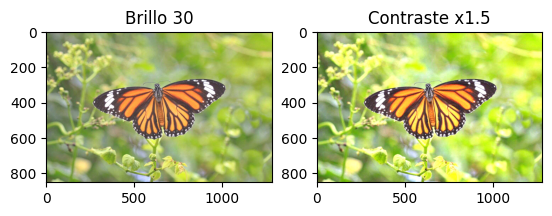

In [203]:
plt.subplot(1, 2, 1)
plt.imshow(imagen_brillo_30)
plt.title('Brillo 30')

plt.subplot(1, 2, 2)
plt.imshow(imagen_contraste_x1_2)
plt.title('Contraste x1.5')

plt.show()

### Histograma

In [46]:
def imhist3(X):
    (N, M, P) = X.shape  # Obtener dimensiones de la imagen
    n = 256  # Número de niveles de colores
    for p in range(3):  # Para cada canal de color
        h = np.zeros((256,))  # Crear un histograma vacío
        for i in range(N):  # Recorrer cada fila
            for j in range(M):  # Recorrer cada columna
                x = X[i, j, p]  # Obtener el valor del píxel
                h[x] += 1  # Incrementar el conteo en el histograma
        plt.figure(figsize=(30, 9))  # Tamaño de la figura
        plt.bar(range(n), h[0:n])  # Mostrar el histograma
        plt.title('Histograma del Canal ' + str(p))  # Título
        plt.show()  # Mostrar figura

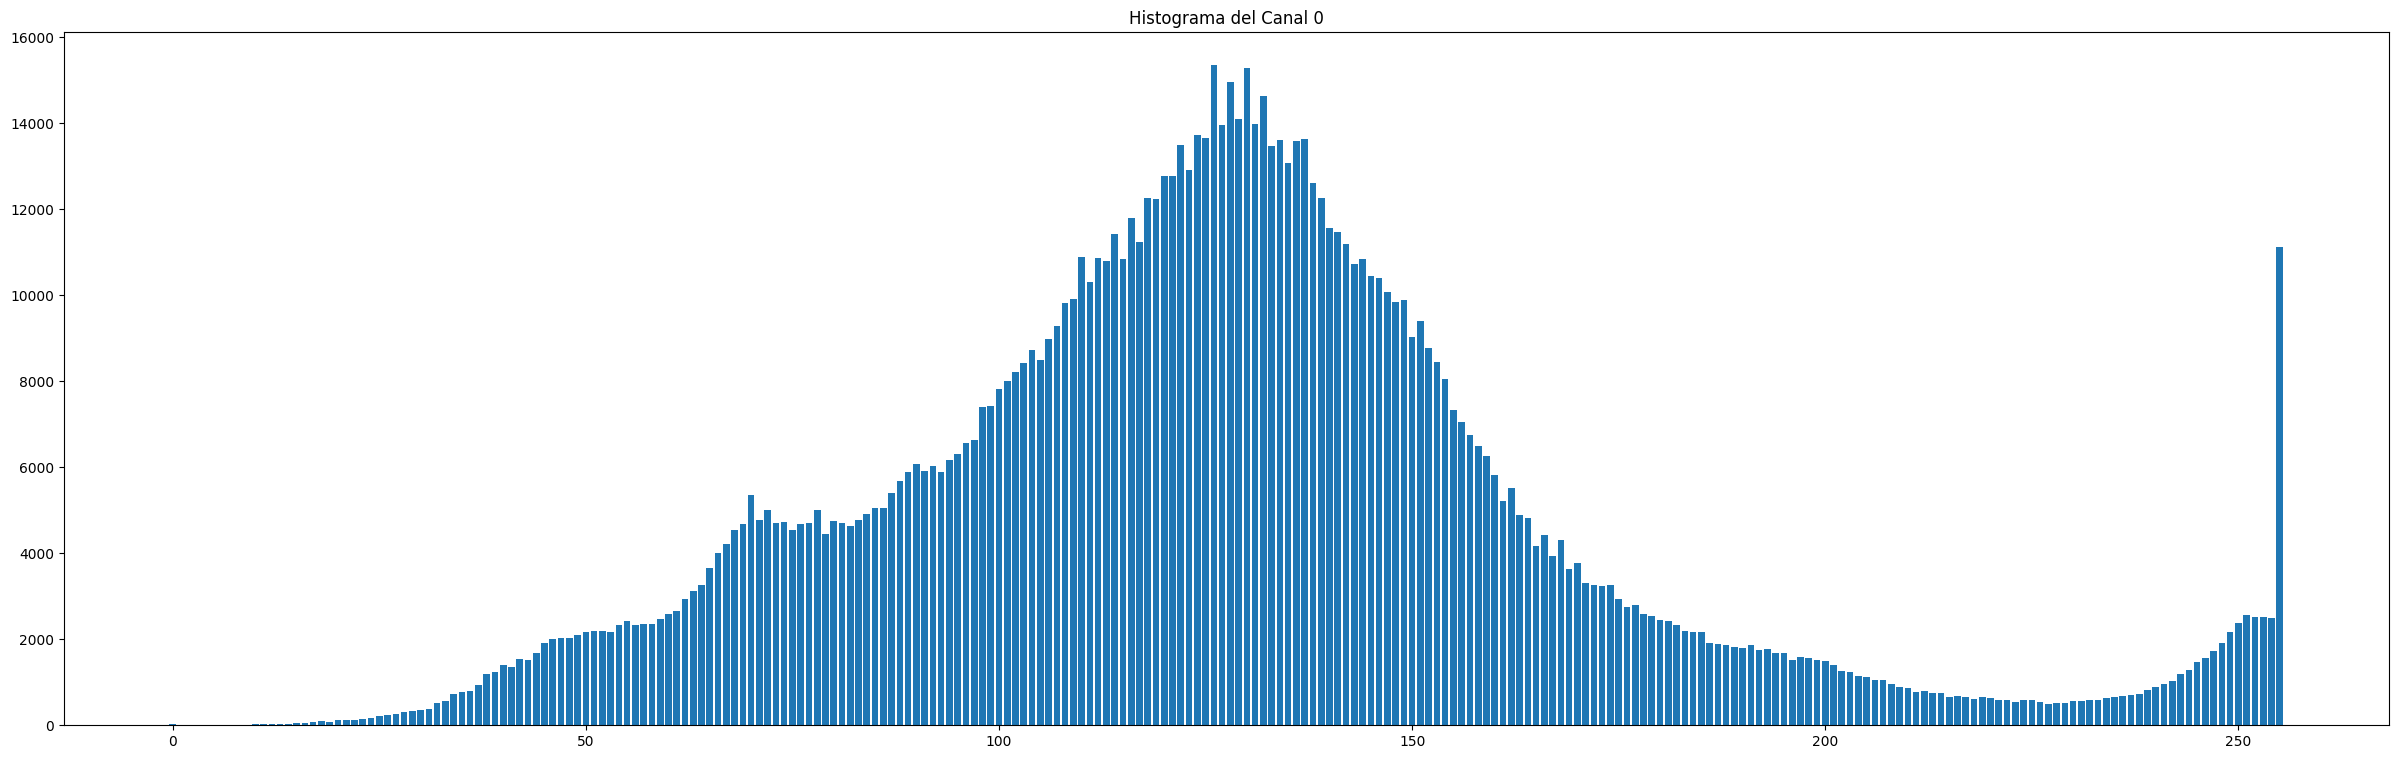

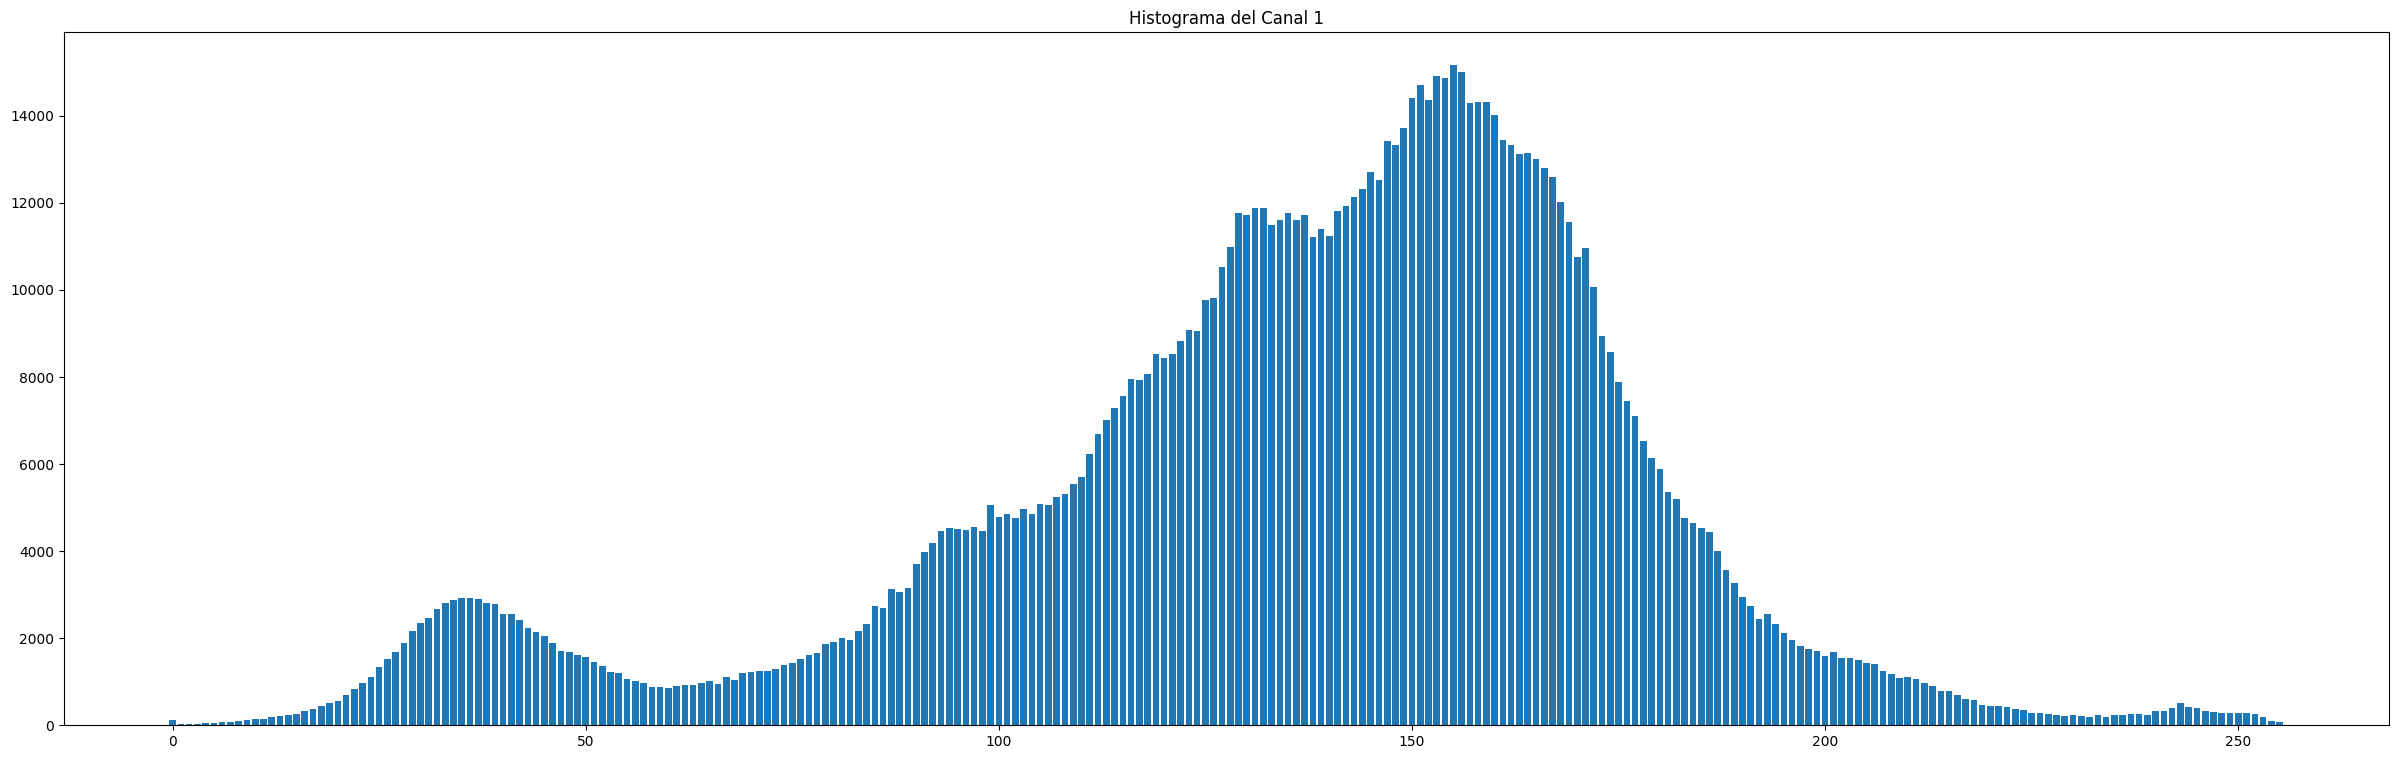

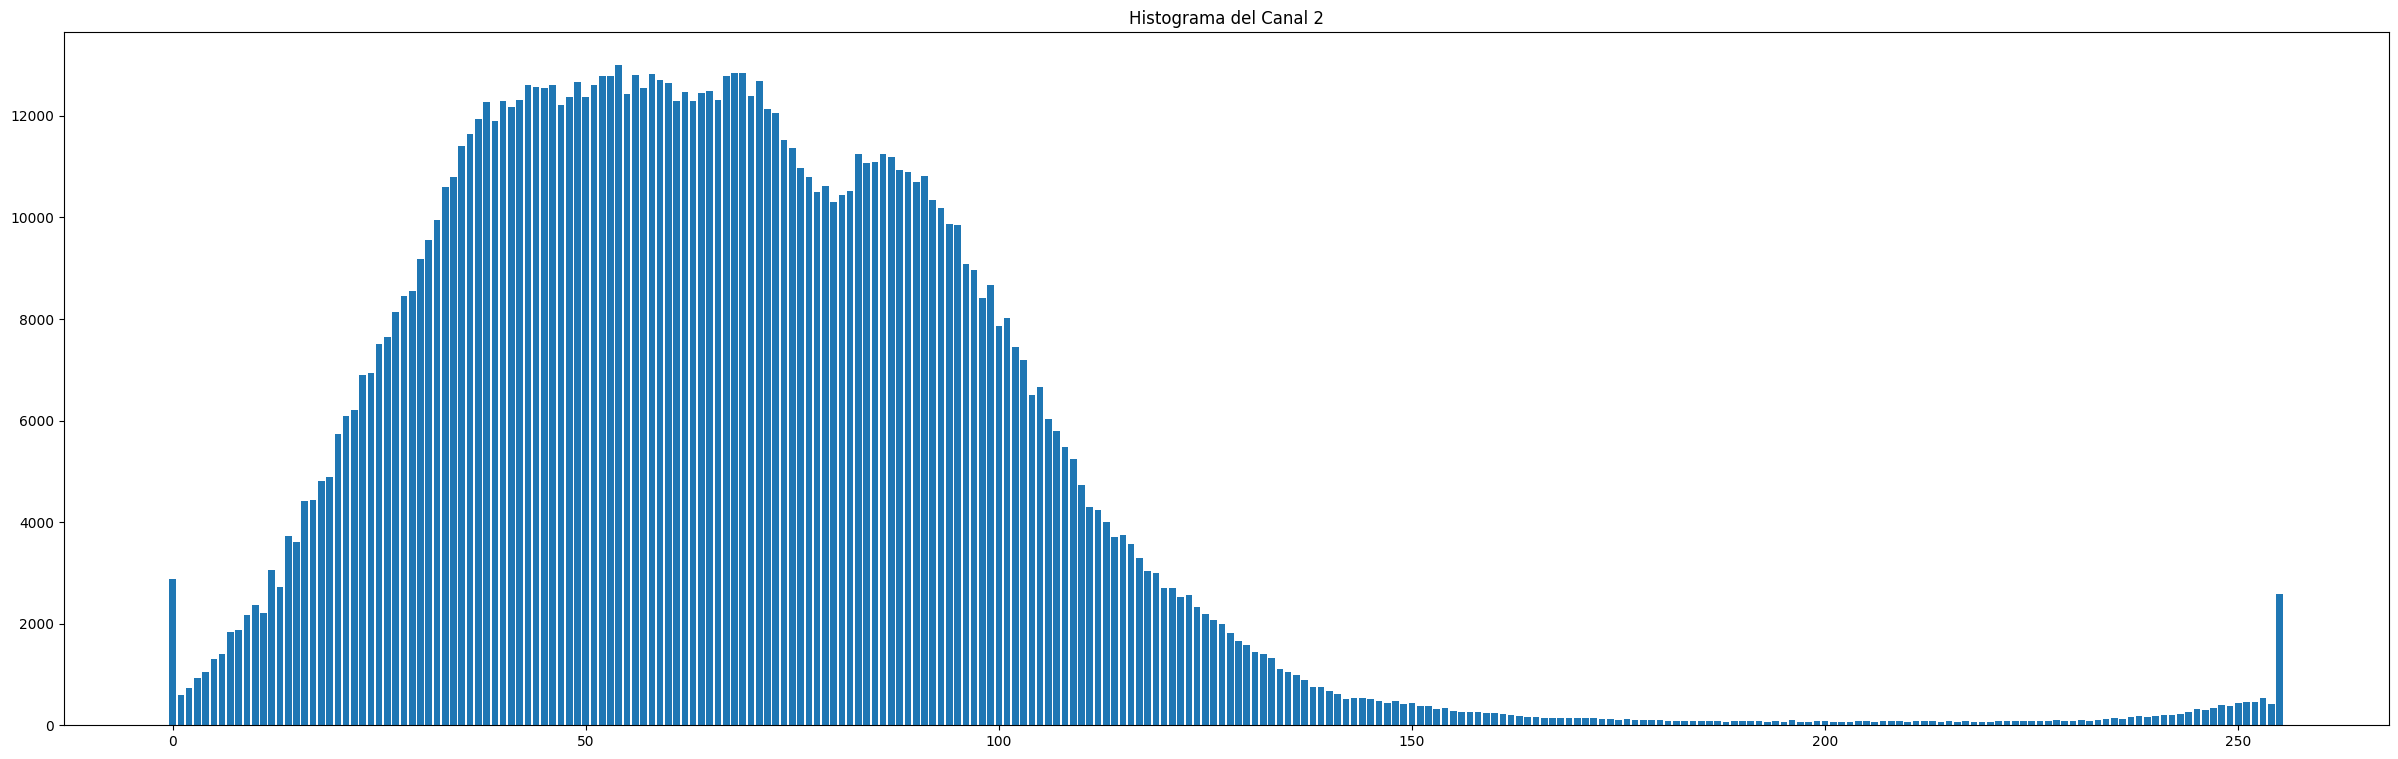

In [47]:
imhist3(imagen)  # Calcular y mostrar el histograma

In [48]:
J = imagen.copy()  # Hacer una copia de la imagen original
J[:, :, 0] = cv2.equalizeHist(imagen[:, :, 0])  # Ecualizar el canal Rojo
J[:, :, 1] = cv2.equalizeHist(imagen[:, :, 1])  # Ecualizar el canal Verde
J[:, :, 1] = cv2.equalizeHist(imagen[:, :, 1])  # Ecualizar el canal Azul

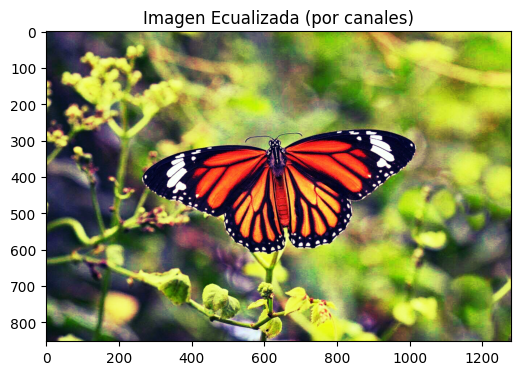

In [49]:
plt.figure(figsize=(6, 9))  # Tamaño de la figura
plt.imshow(J)  # Mostrar la imagen ecualizada
plt.title('Imagen Ecualizada (por canales)')  # Título
plt.show()  # Mostrar

##4. ¡A segmentar por color!
Ahora viene una parte muy interesante: vamos a separar objetos de la imagen por su color.

Convertir a HSV: Vamos a pasar la imagen de RGB a HSV (Hue, Saturation, Value) porque es más fácil definir rangos de color en HSV.

Definir el rango de color: Vamos a establecer los límites inferior y superior del color que queremos segmentar. En el ejemplo, segmentamos el color rojo de las flores. ¡Presten mucha atención acá! Van a tener que ajustar estos valores para su propia imagen.

Crear una máscara: Con cv2.inRange(), vamos a crear una máscara que nos indique qué píxeles están dentro del rango de color y cuáles no.

Aplicar la máscara: Usaremos cv2.bitwise_and() para quedarnos solo con la parte de la imagen que corresponde al color que elegimos.

In [50]:
# Umbralización: Convertir la imagen a blanco y negro
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
_, imagen_umbralizada = cv2.threshold(imagen_gris, 128, 255, cv2.THRESH_BINARY)
# El segundo valor (128) es el umbral.  Si el píxel es menor a 128, se vuelve negro (0), si es mayor, se vuelve blanco (255).

limite_inferior_mariposa = np.array([100, 30, 10])  # Ejemplo para tonos azules
limite_superior_mariposa = np.array([255, 100, 100]) # Ejemplo para tonos azules

In [189]:
imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_RGB2HSV)
# Ajustar estos valores para que coincidan con el color de la mariposa
# Puedes usar herramientas como un selector de color HSV para encontrar los valores adecuados.
# Por ejemplo, si la mariposa tiene tonos azules/violetas, los rangos serán diferentes.
# Estos son solo valores de ejemplo, necesitarás ajustarlos.
limite_inferior_mariposa = np.array([10, 100, 20])  # Ejemplo para tonos azules
limite_superior_mariposa = np.array([25, 255, 255]) # Ejemplo para tonos azules
mascara_mariposa = cv2.inRange(imagen_hsv, limite_inferior_mariposa, limite_superior_mariposa)  # Crear una máscara para el color de la mariposa
imagen_segmentada_mariposa= cv2.bitwise_and(imagen, imagen, mask=mascara_mariposa)  # Aplicar la máscara a la imagen original

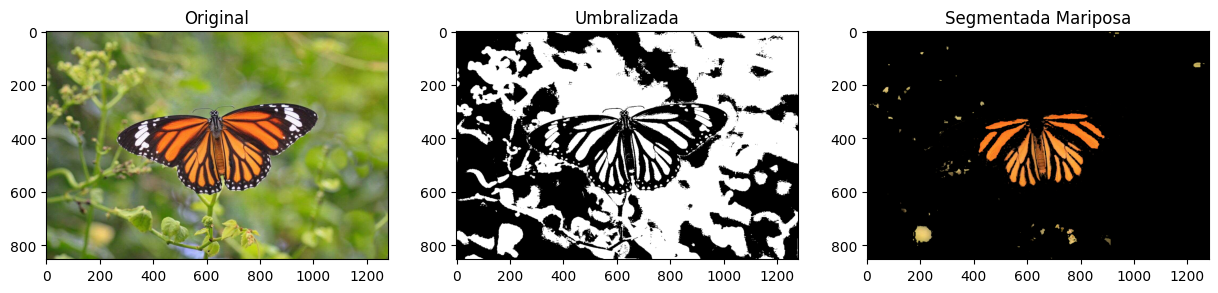

In [190]:
# Mostrar los resultados
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen)
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.title('Umbralizada')
plt.subplot(1, 3, 3)
plt.imshow(imagen_segmentada_mariposa)
plt.title('Segmentada Mariposa')
plt.show()

##5. ¡Dibujando y escribiendo sobre la imagen!
Para terminar, vamos a agregarle un poco de información a nuestra imagen segmentada.

Dibujar rectángulos: Con cv2.findContours() vamos a encontrar los contornos de los objetos que segmentamos, y con cv2.boundingRect() vamos a obtener las coordenadas para dibujar un rectángulo alrededor de ellos. Usaremos cv2.rectangle() para dibujar el rectángulo.

Agregar texto: Con cv2.putText(), vamos a agregar un texto que describa los objetos que segmentamos.

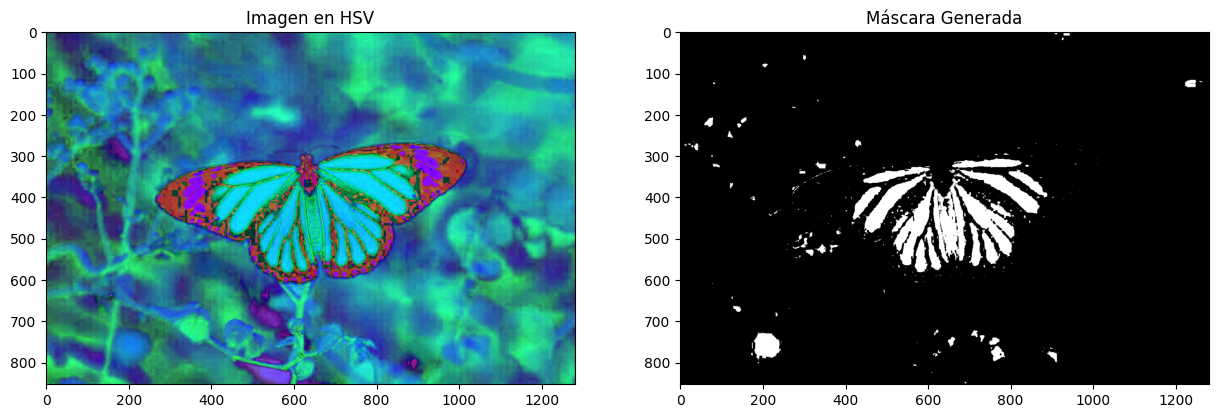

In [191]:
# Visualizar la imagen HSV y la máscara para ajustar los rangos de color
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagen_hsv)
plt.title('Imagen en HSV')

plt.subplot(1, 2, 2)
plt.imshow(mascara_mariposa, cmap='gray')
plt.title('Máscara Generada')

plt.show()

In [192]:
# Momento de la detección!
print("Ejecutando la detección de contornos...")

# Usar la máscara de la mariposa para encontrar contornos
contornos, jerarquia = cv2.findContours(
    mascara_mariposa,         # Usamos la máscara de la mariposa
    cv2.RETR_EXTERNAL,        # Solo contornos externos
    cv2.CHAIN_APPROX_SIMPLE   # Aproximación simple
)

print("Detección completada!")
print("\nResultados del análisis:")
print(f"   Número de contornos encontrados: {len(contornos)}")
print(f"   Tipo de dato de 'contornos': {type(contornos)}")
print(f"   Tipo de dato de 'jerarquia': {type(jerarquia)}")

if len(contornos) > 0:
    # Encontrar el contorno con el área más grande (asumiendo que es la mariposa)
    contorno_principal = max(contornos, key=cv2.contourArea)

    print(f"\nAnálisis del contorno principal encontrado:")
    print(f"   Forma del contorno: {contorno_principal.shape}")
    print(f"   Número de puntos: {len(contorno_principal)}")
    print(f"   Tipo de datos: {contorno_principal.dtype}")

    # Mostramos algunos puntos del contorno
    print(f"\nPrimeros 3 puntos del contorno principal:")
    for i in range(min(3, len(contorno_principal))):
        punto = contorno_principal[i][0]  # [0] porque OpenCV usa formato [[x,y]]
        print(f"   Punto {i+1}: ({punto[0]}, {punto[1]})")

    print(f"\nEl algoritmo encontró {len(contorno_principal)} puntos críticos en el contorno principal")
    print(f"   (puntos donde la dirección del contorno cambia)")

    # Calcular el centroide del contorno principal
    M = cv2.moments(contorno_principal)
    if M["m00"] != 0:
        centroide_x_int = int(M["m10"] / M["m00"])
        centroide_y_int = int(M["m01"] / M["m00"])
        print(f"\nCentroide del contorno principal: ({centroide_x_int}, {centroide_y_int})")
    else:
        centroide_x_int, centroide_y_int = -1, -1
        print("\nNo se pudo calcular el centroide (división por cero)")

else:
    print("No se encontraron contornos")
    centroide_x_int, centroide_y_int = -1, -1

Ejecutando la detección de contornos...
Detección completada!

Resultados del análisis:
   Número de contornos encontrados: 315
   Tipo de dato de 'contornos': <class 'tuple'>
   Tipo de dato de 'jerarquia': <class 'numpy.ndarray'>

Análisis del contorno principal encontrado:
   Forma del contorno: (1113, 1, 2)
   Número de puntos: 1113
   Tipo de datos: int32

Primeros 3 puntos del contorno principal:
   Punto 1: (661, 355)
   Punto 2: (661, 357)
   Punto 3: (660, 358)

El algoritmo encontró 1113 puntos críticos en el contorno principal
   (puntos donde la dirección del contorno cambia)

Centroide del contorno principal: (657, 466)


🎨 Preparando visualización científica

🔄 Usando copia de la imagen original a color para visualización:
   Forma: (853, 1280, 3)
   Canales: RGB

🖌️ Dibujando contorno:
   Color usado: (0, 255, 0) (BGR)
   Grosor: 2 píxeles
   Contornos dibujados: 1

🎯 Dibujando centroide:
   Posición: (657, 466)
   Color: (0, 0, 255) (BGR)
   Radio: 5 píxeles
   Etiqueta agregada

OK Imagen de visualización preparada


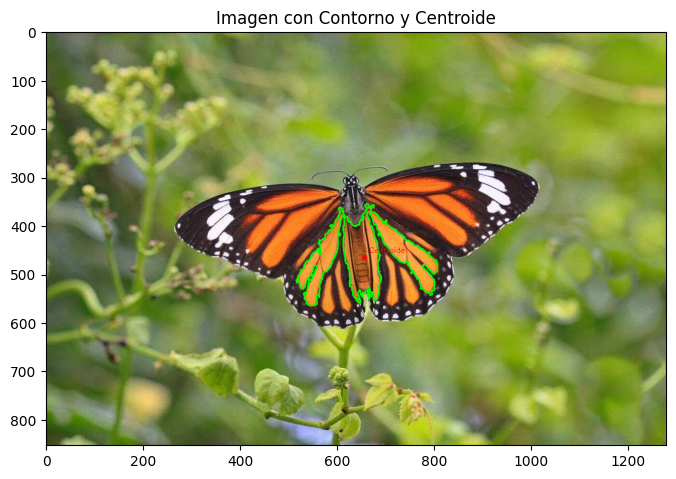

In [193]:
# Preparar imagen para visualización
print("🎨 Preparando visualización científica")

# Usar una copia de la imagen original a color para dibujar
# Aseguramos que la imagen esté en formato BGR para las funciones de dibujo de OpenCV
imagen_visualizacion = imagen.copy()
imagen_visualizacion_bgr = cv2.cvtColor(imagen_visualizacion, cv2.COLOR_RGB2BGR)

print(f"\n🔄 Usando copia de la imagen original a color para visualización:")
print(f"   Forma: {imagen_visualizacion.shape}")
print(f"   Canales: RGB")


if len(contornos) > 0:
    # Dibujar el contorno
    print(f"\n🖌️ Dibujando contorno:")
    color_contorno = (0, 255, 0)  # Verde en formato BGR
    grosor = 2

    cv2.drawContours(
        imagen_visualizacion_bgr,    # Imagen destino (se modifica)
        [contorno_principal],    # Lista de contornos
        -1,                      # Índice (-1 = todos los contornos)
        color_contorno,          # Color BGR
        grosor                   # Grosor en píxeles
    )

    print(f"   Color usado: {color_contorno} (BGR)")
    print(f"   Grosor: {grosor} píxeles")
    print(f"   Contornos dibujados: 1")

    # Dibujar el centroide
    if centroide_x_int != -1 and centroide_y_int != -1:
        print(f"\n🎯 Dibujando centroide:")
        color_centroide = (0, 0, 255)  # Rojo en formato BGR
        radio = 5

        cv2.circle(
            imagen_visualizacion_bgr,           # Imagen destino
            (centroide_x_int, centroide_y_int),  # Centro del círculo
            radio,                          # Radio
            color_centroide,               # Color BGR
            -1                             # Grosor (-1 = relleno)
        )

        print(f"   Posición: ({centroide_x_int}, {centroide_y_int})")
        print(f"   Color: {color_centroide} (BGR)")
        print(f"   Radio: {radio} píxeles")

        # Agregar etiqueta de texto
        cv2.putText(
            imagen_visualizacion_bgr,
            'Centroide',
            (centroide_x_int + 10, centroide_y_int - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color_centroide,
            1
        )

        print(f"   Etiqueta agregada")

else:
    print("ERROR No hay contornos para dibujar")

# Convertir de nuevo a RGB para mostrar con Matplotlib
imagen_visualizacion_rgb = cv2.cvtColor(imagen_visualizacion_bgr, cv2.COLOR_BGR2RGB)


print(f"\nOK Imagen de visualización preparada")

# Mostrar la imagen con contornos y centroide
plt.figure(figsize=(8, 8))
plt.imshow(imagen_visualizacion_rgb)
plt.title('Imagen con Contorno y Centroide')
plt.show()

##6. Presentaciones preliminares

Cada uno/una de ustedes va a tener 5 minutos para mostrarnos su trabajo, que debe incluir:

La imagen original.

La imagen mejorada (ya sea con ajuste de brillo/contraste o ecualización de histograma).

La imagen segmentada.

Una explicación de todo el proceso, incluyendo:

La imagen que eligieron y por qué.

Los valores que usaron para ajustar el brillo y el contraste (si lo hicieron).

El rango de color HSV que eligieron para segmentar y por qué.

Cualquier dificultad que hayan tenido y cómo la resolvieron.

## Recursos

### Datasets Generales:

**[COCO](https://cocodataset.org/) (Common Objects in Context):** Este dataset es muy completo, con imágenes de objetos cotidianos en escenas complejas. Es ideal para practicar segmentación y reconocimiento de objetos.

**Ideas para el proyecto:** Segmentar diferentes objetos en una escena (personas, autos, animales) y analizar sus relaciones espaciales.


**[Open Images](https://storage.googleapis.com/openimages/web/index.html):** Un dataset masivo con millones de imágenes y anotaciones de objetos. Ofrece una gran variedad de temas y es excelente para proyectos más ambiciosos.

**Ideas para el proyecto:** Detectar y segmentar múltiples objetos en una imagen, o incluso intentar segmentar objetos dentro de un contexto específico (por ejemplo, segmentar diferentes tipos de árboles en un paisaje).


**[ImageNet](https://www.image-net.org/):** Este dataset contiene una gran cantidad de imágenes organizadas según la jerarquía de WordNet.

**Ideas para el Proyecto:** Los estudiantes pueden usar un subconjunto de ImageNet para segmentar y clasificar diferentes categorías de imágenes, como animales, vehículos o plantas.


### Datasets Específicos:

**[Flores](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html):** Datasets como Oxford Flowers 102 son perfectos para proyectos de segmentación por color, donde los estudiantes pueden aislar flores de diferentes tipos y colores.

**Ideas para el proyecto:** Segmentar flores de un color específico y luego usar técnicas de procesamiento de imágenes para analizar su forma o textura.


**[Rostros](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html):** Datasets como CelebA pueden usarse para proyectos de segmentación de características faciales o reconocimiento de rostros.

**Ideas para el proyecto:** Segmentar diferentes partes del rostro (ojos, nariz, boca) y analizar cómo cambian con las expresiones faciales.


**[Paisajes Urbanos](https://www.cityscapes-dataset.com/):** Cityscapes es ideal para segmentar elementos en entornos urbanos, como autos, peatones y edificios.

### Dónde Encontrar Más Datasets:

**[Kaggle](https://www.kaggle.com/datasets?search=image):** Esta plataforma ofrece una gran variedad de datasets de imágenes subidos por la comunidad, que pueden ser útiles para proyectos específicos.


**[Papers With Code](https://paperswithcode.com/datasets?mod=images):** Este sitio web recopila datasets utilizados en investigaciones de aprendizaje automático, incluyendo muchos datasets de imágenes.
Usa el código con precaución